---
## 1. Librairies et constantes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import gc
import os
from scipy.optimize import curve_fit

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

Rd      = 287.05
Rv      = 461.5
EPSILON = Rd / Rv

DIR_3D = '3D'
DIR_2D = '2D'
DIR_1D = '1D'

def path3d(var):
    return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')

def path2d(var):
    return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{var}.nc')

def path1d(var):
    return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{var}.nc')

BLOC = 2
dx   = 2000.0
dy   = 2000.0

print('Prêt.')

Prêt.


---
## 2. Dimensions de la grille

In [3]:
_ds = xr.open_dataset(path3d('ua'))
_da = _ds['ua']

dim_t = _da.dims[0]
dim_z = _da.dims[1]
dim_y = _da.dims[2]
dim_x = _da.dims[3]

n_t = _da.sizes[dim_t]
n_z = _da.sizes[dim_z]
n_y = _da.sizes[dim_y]
n_x = _da.sizes[dim_x]
times = _da[dim_t].values.copy()

_ds.close()
del _ds, _da
gc.collect()

# altitude depuis le fichier 1D (valeurs en mètres)
_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.copy()
_ds1.close()
del _ds1
gc.collect()

t_stat   = int(2 * n_t / 3)
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat
time_days = times.astype('float64') // 4

print(f'Grille : {n_t} t  x  {n_z} z  x  {n_y} y  x  {n_x} x')
print(f'Altitude : {alt[0]:.0f} — {alt[-1]:.0f} m')
print(f'État stationnaire : t={t_stat} → {n_t-1}  ({n_stat} pas)')

Grille : 100 t  x  74 z  x  128 y  x  2000 x
Altitude : 0 — 32500 m
État stationnaire : t=66 → 99  (34 pas)


---
## 3. Masques humide / sec (PRW)

In [4]:
ds_prw   = xr.open_dataset(path2d('prw'))
prw_all  = ds_prw['prw'].load()
ds_prw.close()

prw_mean  = prw_all.isel({dim_t: idx_stat}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))

mh = (prw_mean.values > PRW_SEUIL)
ms = ~mh

del prw_all
gc.collect()

print(f'Seuil PRW : {PRW_SEUIL:.1f} kg/m²')
print(f'Humide : {mh.mean()*100:.1f}%   Sec : {ms.mean()*100:.1f}%')

Seuil PRW : 30.4 kg/m²
Humide : 42.3%   Sec : 57.7%


---
## 4. Profil ρ₀

In [5]:
rho0_sum = np.zeros(n_z)
n_rho    = 0

ds_ta  = xr.open_dataset(path3d('ta'))
ds_pa  = xr.open_dataset(path3d('pa'))
ds_hus = xr.open_dataset(path3d('hus'))

for t0 in range(t_stat, n_t, BLOC):
    t1     = min(t0 + BLOC, n_t)
    sl     = {dim_t: slice(t0, t1)}
    T_blk  = ds_ta['ta'].isel(sl).values
    p_blk  = ds_pa['pa'].isel(sl).values
    qv_blk = ds_hus['hus'].isel(sl).values
    Tv_blk = T_blk * (1.0 + qv_blk / EPSILON) / (1.0 + qv_blk)
    rho_blk = p_blk / (Rd * Tv_blk)
    rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)
    n_rho    += (t1 - t0)
    del T_blk, p_blk, qv_blk, Tv_blk, rho_blk
    gc.collect()

ds_ta.close() ; ds_pa.close() ; ds_hus.close()
del ds_ta, ds_pa, ds_hus
gc.collect()

rho0 = rho0_sum / n_rho

print(f'ρ₀ calculé sur {n_rho} pas de temps.')
print(f'  Surface : {rho0[0]:.3f} kg/m³')
print(f'  ~10 km  : {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m³')

ρ₀ calculé sur 34 pas de temps.
  Surface : 1.183 kg/m³
  ~10 km  : 0.410 kg/m³


# §17 — Paramétrisation polynome flux de reynolds — Notebook autonome
Recalcule tout depuis zéro : imports, dimensions, ρ₀, masques humide/sec, flux de Reynolds par région, puis fit analytique.

---
## 5. Fonction utilitaire

In [6]:
def tendance(flux_profil):
    """Force de Reynolds : -1/rho0 · d(rho0 <u'w'>) / dz"""
    return -np.gradient(flux_profil, alt) / rho0

---
## 6. Calcul des flux de Reynolds par région (§16)

Calcule `flux_loc_h/s` (anomalies intra-région) et `flux_glob_h/s` (anomalies domaine entier)  
niveau par niveau pour économiser la RAM.

In [7]:
flux_loc_h  = np.zeros(n_z)
flux_loc_s  = np.zeros(n_z)
flux_glob_h = np.zeros(n_z)
flux_glob_s = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):

    acc_loc_h  = 0.0 ; acc_loc_s  = 0.0
    acc_glob_h = 0.0 ; acc_glob_s = 0.0
    n = 0

    for it in range(t_stat, n_t):

        u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values

        # anomalies locales (intra-région)
        u_h = u_2d[mh] ; u_s = u_2d[ms]
        w_h = w_2d[mh] ; w_s = w_2d[ms]
        acc_loc_h += ((u_h - u_h.mean()) * (w_h - w_h.mean())).mean()
        acc_loc_s += ((u_s - u_s.mean()) * (w_s - w_s.mean())).mean()

        # anomalies globales (domaine entier)
        u_p = u_2d - u_2d.mean()
        w_p = w_2d - w_2d.mean()
        acc_glob_h += (u_p * w_p)[mh].mean()
        acc_glob_s += (u_p * w_p)[ms].mean()

        n += 1
        del u_2d, w_2d, u_h, u_s, w_h, w_s, u_p, w_p
        gc.collect()

    flux_loc_h[iz]  = rho0[iz] * acc_loc_h  / n
    flux_loc_s[iz]  = rho0[iz] * acc_loc_s  / n
    flux_glob_h[iz] = rho0[iz] * acc_glob_h / n
    flux_glob_s[iz] = rho0[iz] * acc_glob_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

print('Flux calculés.')

  iz=0/73  (0 m)
  iz=10/73  (1331 m)
  iz=20/73  (6000 m)
  iz=30/73  (11000 m)
  iz=40/73  (16000 m)
  iz=50/73  (21000 m)
  iz=60/73  (26000 m)
  iz=70/73  (31000 m)
Flux calculés.


---
## §17 — Étape 1 : visualisation du profil de référence

Observer : zéros en surface et au sommet convectif, localisation de l'extremum, changement de signe éventuel.

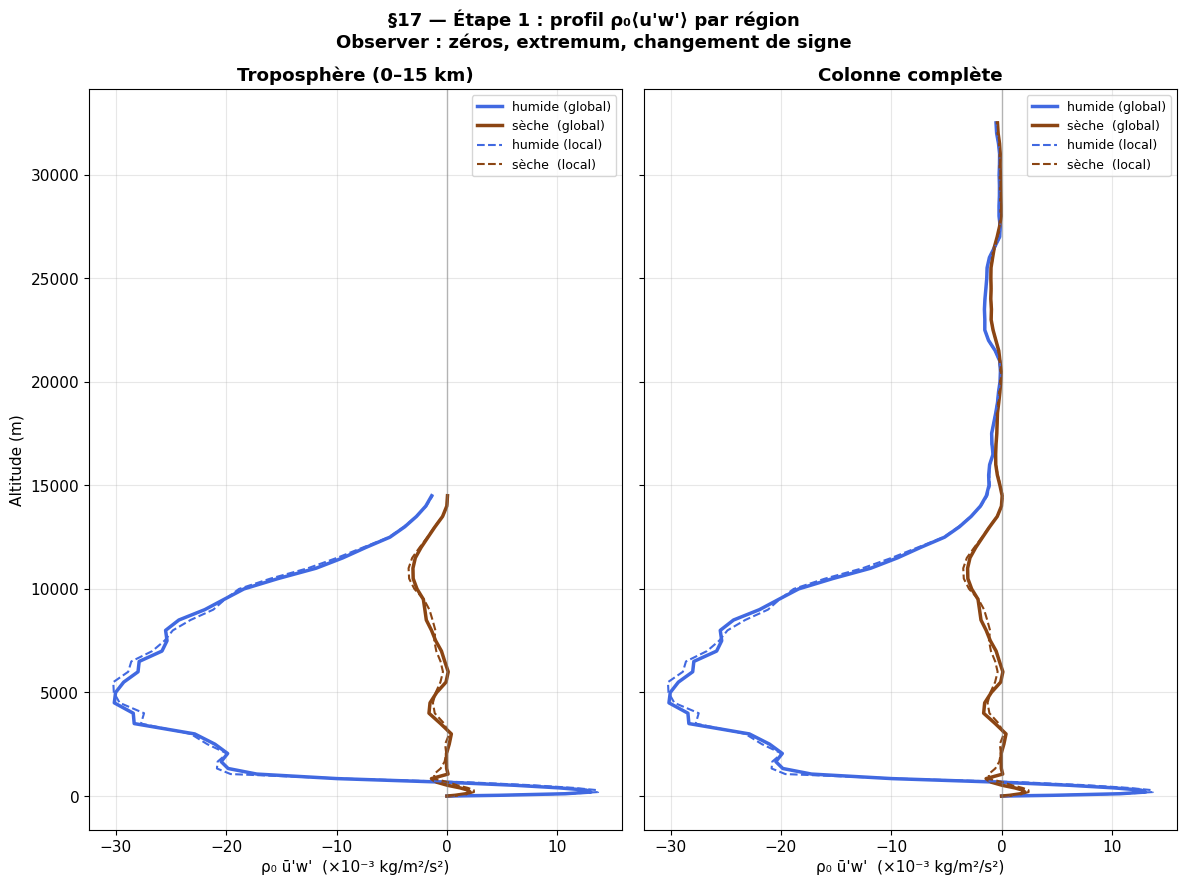

── Région HUMIDE (global) ──
  min  : -30.1505 ×10⁻³  à z = 4500 m
  max  : 13.0515 ×10⁻³  à z = 194 m
  surface (iz=0)   : 0.0000 ×10⁻³
  z≈15 km          : -1.1430 ×10⁻³

── Région SÈCHE  (global) ──
  min  : -3.0802 ×10⁻³  à z = 11000 m
  max  : 2.1031 ×10⁻³  à z = 194 m
  surface (iz=0)   : 0.0000 ×10⁻³
  z≈15 km          : -0.1504 ×10⁻³



In [8]:
idx_tropo = np.searchsorted(alt, 15000)
sc = 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl], color='royalblue',   lw=2.5, label='humide (global)')
    ax.plot(flux_glob_s[sl] * sc, alt[sl], color='saddlebrown', lw=2.5, label='sèche  (global)')
    ax.plot(flux_loc_h[sl]  * sc, alt[sl], color='royalblue',   lw=1.5, linestyle='--', label='humide (local)')
    ax.plot(flux_loc_s[sl]  * sc, alt[sl], color='saddlebrown', lw=1.5, linestyle='--', label='sèche  (local)')
    ax.axvline(0, color='grey', alpha=0.5, lw=1)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(
    '§17 — Étape 1 : profil ρ₀⟨u\'w\'⟩ par région\n'
    'Observer : zéros, extremum, changement de signe',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

for label, flux in [('HUMIDE (global)', flux_glob_h), ('SÈCHE  (global)', flux_glob_s)]:
    phi = flux[:idx_tropo]
    iz_min = np.argmin(phi)
    iz_max = np.argmax(phi)
    print(f'── Région {label} ──')
    print(f'  min  : {phi[iz_min]*sc:.4f} ×10⁻³  à z = {alt[iz_min]:.0f} m')
    print(f'  max  : {phi[iz_max]*sc:.4f} ×10⁻³  à z = {alt[iz_max]:.0f} m')
    print(f'  surface (iz=0)   : {flux[0]*sc:.4f} ×10⁻³')
    print(f'  z≈15 km          : {flux[idx_tropo]*sc:.4f} ×10⁻³')
    print()

---
## §17 — Étape 2 : forme analytique

$$\rho_0\,\overline{u'w'}(z) = A \cdot \frac{z}{z_c} \cdot \left(1 - \frac{z}{z_c}\right)^n, \quad z \leq z_c$$

- $A$ : amplitude (kg/m²/s²)
- $z_c$ : hauteur du sommet convectif (m)
- $n$ : asymétrie — le max se trouve à $z^* = z_c / (1+n)$

/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in sqrt
  val = A * xi * (1.0 - xi)**n
/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


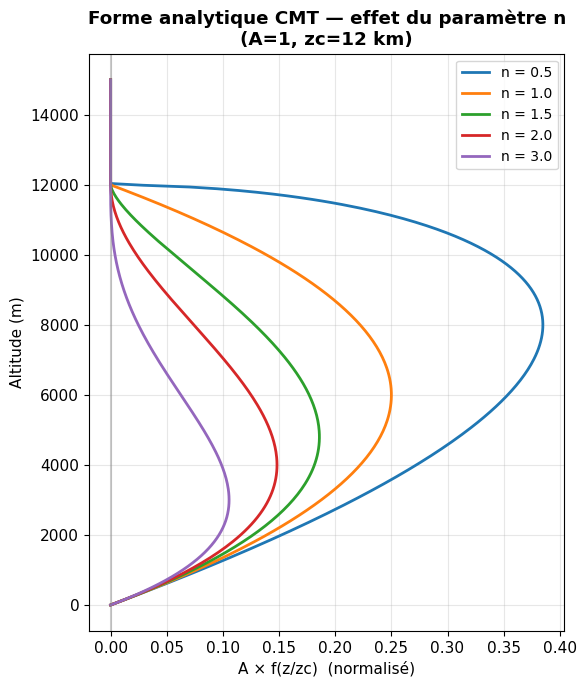

In [9]:
def profil_cmt(z, A, zc, n):
    xi  = z / zc
    val = A * xi * (1.0 - xi)**n
    val = np.where(z > zc, 0.0, val)
    return val

z_test  = np.linspace(0, 15000, 300)

fig, ax = plt.subplots(figsize=(6, 7))
for n_test in [0.5, 1.0, 1.5, 2.0, 3.0]:
    ax.plot(profil_cmt(z_test, A=1.0, zc=12000.0, n=n_test), z_test, lw=2, label=f'n = {n_test}')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('A × f(z/zc)  (normalisé)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Forme analytique CMT — effet du paramètre n\n(A=1, zc=12 km)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## §17 — Étape 3 : fit scipy — région humide

In [10]:
z_fit   = alt[:idx_tropo].astype(float)
phi_fit = flux_glob_h[:idx_tropo]

p0 = [phi_fit.min(), 12000.0, 1.5]

popt_h, _ = curve_fit(profil_cmt, z_fit, phi_fit, p0=p0, maxfev=20000)
A_h, zc_h, n_h = popt_h

print('── Fit région HUMIDE ──')
print(f'  A  = {A_h:.4e} kg/m²/s²')
print(f'  zc = {zc_h/1000:.2f} km')
print(f'  n  = {n_h:.3f}')

── Fit région HUMIDE ──
  A  = -1.6696e-01 kg/m²/s²
  zc = 14.44 km
  n  = 1.609


/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


---
## §17 — Étape 4 : R² et résidus

R² humide = 0.8266
Résidu max : 15.8543 ×10⁻³ kg/m²/s²
Résidu rms : 5.6045 ×10⁻³ kg/m²/s²


/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


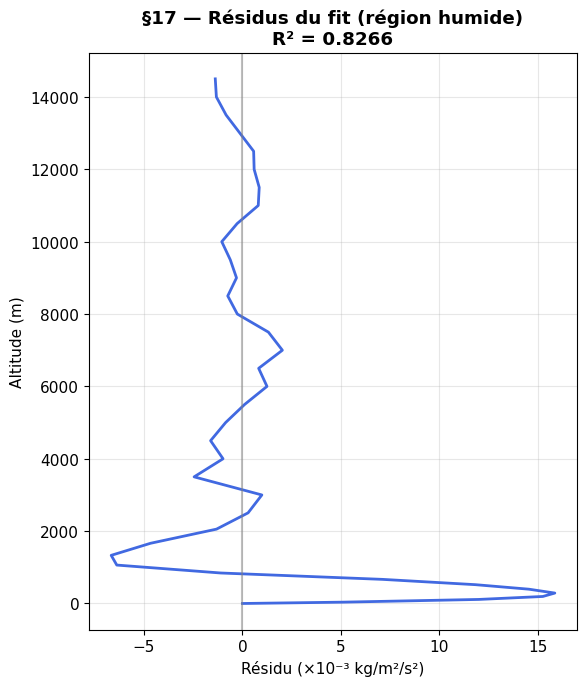

In [11]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1.0 - ss_res / ss_tot

phi_pred_h = profil_cmt(z_fit, *popt_h)
R2_h       = r2_score(phi_fit, phi_pred_h)
residus_h  = phi_fit - phi_pred_h

print(f'R² humide = {R2_h:.4f}')
print(f'Résidu max : {np.abs(residus_h).max()*sc:.4f} ×10⁻³ kg/m²/s²')
print(f'Résidu rms : {np.sqrt((residus_h**2).mean())*sc:.4f} ×10⁻³ kg/m²/s²')

fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(residus_h * sc, z_fit, color='royalblue', lw=2)
ax.axvline(0, color='grey', alpha=0.5)
ax.set_xlabel('Résidu (×10⁻³ kg/m²/s²)')
ax.set_ylabel('Altitude (m)')
ax.set_title(f'§17 — Résidus du fit (région humide)\nR² = {R2_h:.4f}', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## §17 — Étape 5 : visualisation simulation vs fit

/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


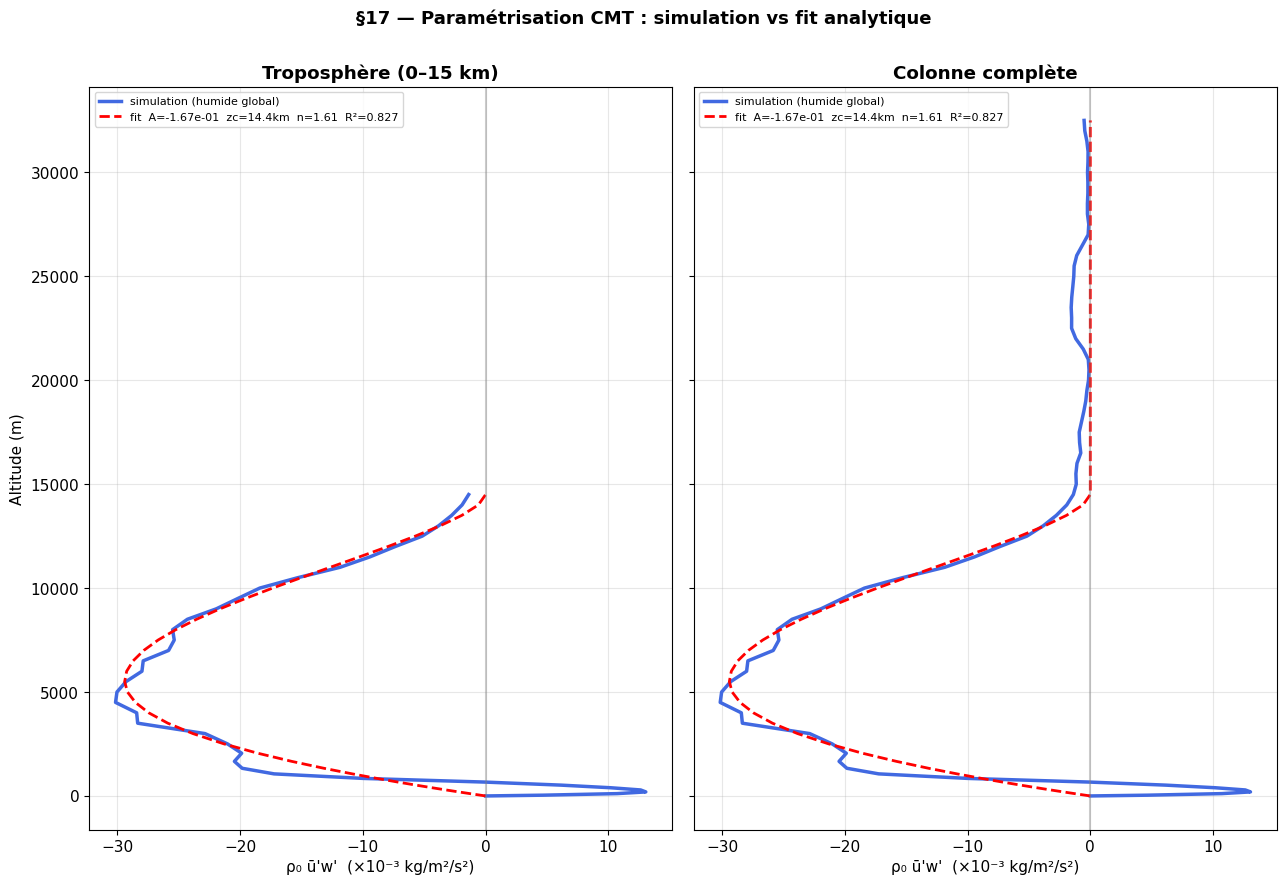

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl],
            color='royalblue', lw=2.5, label='simulation (humide global)')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_h) * sc, alt[sl],
            color='red', lw=2, linestyle='--',
            label=f'fit  A={A_h:.2e}  zc={zc_h/1e3:.1f}km  n={n_h:.2f}  R²={R2_h:.3f}')
    ax.axvline(0, color='grey', alpha=0.4)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(
    '§17 — Paramétrisation CMT : simulation vs fit analytique\n',
    
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## §17 — Étape 6 : fit sur la région sèche + comparaison

/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


── Fit région SÈCHE ──
  A  = -2.4129e-03 kg/m²/s²
  zc = 13.00 km
  n  = -0.036
  R² = 0.5676


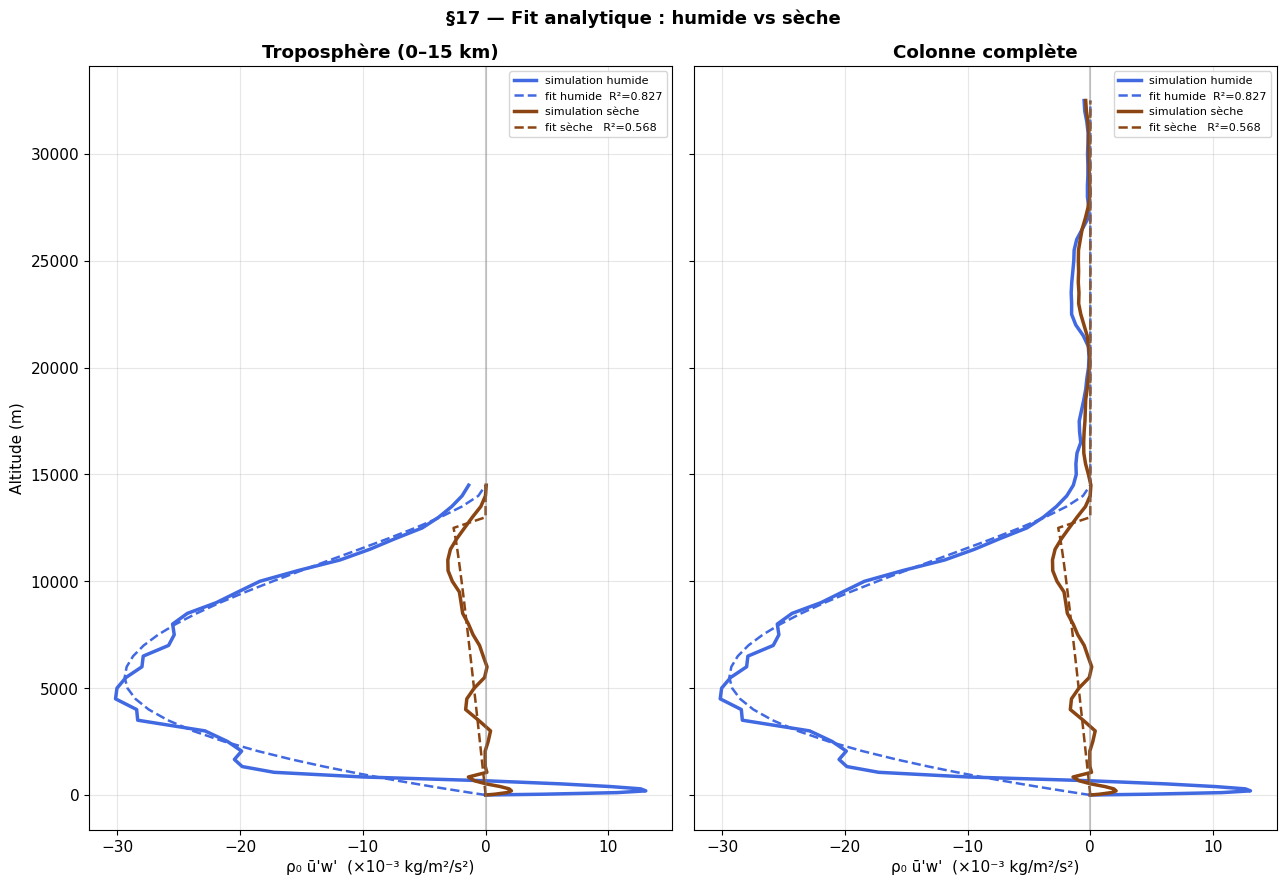

In [13]:
phi_fit_s = flux_glob_s[:idx_tropo]
p0_s = [phi_fit_s.min(), 12000.0, 1.5]

popt_s, _ = curve_fit(profil_cmt, z_fit, phi_fit_s, p0=p0_s, maxfev=20000)
A_s, zc_s, n_s = popt_s

R2_s = r2_score(phi_fit_s, profil_cmt(z_fit, *popt_s))

print('── Fit région SÈCHE ──')
print(f'  A  = {A_s:.4e} kg/m²/s²')
print(f'  zc = {zc_s/1000:.2f} km')
print(f'  n  = {n_s:.3f}')
print(f'  R² = {R2_s:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl], color='royalblue',   lw=2.5, label='simulation humide')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_h) * sc, alt[sl],
            color='royalblue', lw=1.8, linestyle='--', label=f'fit humide  R²={R2_h:.3f}')
    ax.plot(flux_glob_s[sl] * sc, alt[sl], color='saddlebrown', lw=2.5, label='simulation sèche')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_s) * sc, alt[sl],
            color='saddlebrown', lw=1.8, linestyle='--', label=f'fit sèche   R²={R2_s:.3f}')
    ax.axvline(0, color='grey', alpha=0.4)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle('§17 — Fit analytique : humide vs sèche', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## §17 — Étape 7 : tableau de synthèse

In [14]:
z_max_h = zc_h / (1 + n_h)
z_max_s = zc_s / (1 + n_s)

print('=' * 55)
print(f'{"Paramètre":<22} {"Humide":>14} {"Sèche":>14}')
print('=' * 55)
print(f'{"A (kg/m²/s²)":<22} {A_h:>14.4e} {A_s:>14.4e}')
print(f'{"zc (km)":<22} {zc_h/1000:>14.2f} {zc_s/1000:>14.2f}')
print(f'{"n":<22} {n_h:>14.3f} {n_s:>14.3f}')
print(f'{"R²":<22} {R2_h:>14.4f} {R2_s:>14.4f}')
print(f'{"z_max = zc/(1+n) (km)":<22} {z_max_h/1000:>14.2f} {z_max_s/1000:>14.2f}')
print('=' * 55)

Paramètre                      Humide          Sèche
A (kg/m²/s²)              -1.6696e-01    -2.4129e-03
zc (km)                         14.44          13.00
n                               1.609         -0.036
R²                             0.8266         0.5676
z_max = zc/(1+n) (km)            5.54          13.49


---
## §17 — Étape 8 : robustesse temporelle (early vs late)

  iz=0/73
  iz=10/73
  iz=20/73
  iz=30/73
  iz=40/73
  iz=50/73
  iz=60/73
  iz=70/73

             A (kg/m²/s²)    zc (km)        n       R²
early         -1.5624e-01      14.94    1.691   0.7995
late          -1.7586e-01      13.97    1.519   0.8279
full          -1.6696e-01      14.44    1.609   0.8266


/tmp/ipykernel_5744/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


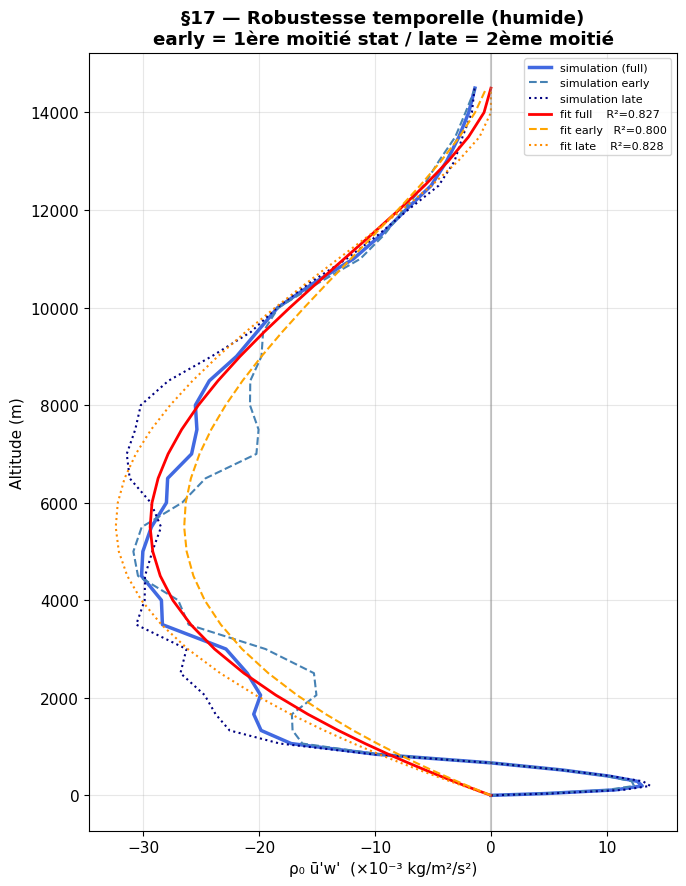

In [15]:
t_mid = t_stat + (n_t - t_stat) // 2

flux_early_h = np.zeros(n_z)
flux_late_h  = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    for flux_arr, t0, t1 in [
        (flux_early_h, t_stat, t_mid),
        (flux_late_h,  t_mid,  n_t),
    ]:
        acc = 0.0
        n   = 0
        for it in range(t0, t1):
            u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
            w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values
            u_p  = u_2d - u_2d.mean()
            w_p  = w_2d - w_2d.mean()
            acc += (u_p * w_p)[mh].mean()
            n   += 1
            del u_2d, w_2d, u_p, w_p
        flux_arr[iz] = rho0[iz] * acc / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

popt_early, _ = curve_fit(profil_cmt, z_fit, flux_early_h[:idx_tropo], p0=p0, maxfev=20000)
popt_late,  _ = curve_fit(profil_cmt, z_fit, flux_late_h[:idx_tropo],  p0=p0, maxfev=20000)

R2_early = r2_score(flux_early_h[:idx_tropo], profil_cmt(z_fit, *popt_early))
R2_late  = r2_score(flux_late_h[:idx_tropo],  profil_cmt(z_fit, *popt_late))

print()
print(f'{"":<8} {"A (kg/m²/s²)":>16} {"zc (km)":>10} {"n":>8} {"R²":>8}')
print(f'{"early":<8} {popt_early[0]:>16.4e} {popt_early[1]/1e3:>10.2f} {popt_early[2]:>8.3f} {R2_early:>8.4f}')
print(f'{"late":<8} {popt_late[0]:>16.4e} {popt_late[1]/1e3:>10.2f} {popt_late[2]:>8.3f} {R2_late:>8.4f}')
print(f'{"full":<8} {A_h:>16.4e} {zc_h/1e3:>10.2f} {n_h:>8.3f} {R2_h:>8.4f}')

fig, ax = plt.subplots(figsize=(7, 9))
ax.plot(flux_glob_h[:idx_tropo]   * sc, z_fit, color='royalblue',  lw=2.5, label='simulation (full)')
ax.plot(flux_early_h[:idx_tropo]  * sc, z_fit, color='steelblue',  lw=1.5, linestyle='--', label='simulation early')
ax.plot(flux_late_h[:idx_tropo]   * sc, z_fit, color='navy',       lw=1.5, linestyle=':',  label='simulation late')
ax.plot(profil_cmt(z_fit, *popt_h)     * sc, z_fit, color='red',       lw=2,   label=f'fit full    R²={R2_h:.3f}')
ax.plot(profil_cmt(z_fit, *popt_early) * sc, z_fit, color='orange',    lw=1.5, linestyle='--', label=f'fit early   R²={R2_early:.3f}')
ax.plot(profil_cmt(z_fit, *popt_late)  * sc, z_fit, color='darkorange', lw=1.5, linestyle=':', label=f'fit late    R²={R2_late:.3f}')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
ax.set_ylabel('Altitude (m)')
ax.set_title('§17 — Robustesse temporelle (humide)\nearly = 1ère moitié stat / late = 2ème moitié', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Profil des vents u et v par région

In [16]:
lux_loc_h  = np.zeros(n_z)
flux_loc_s  = np.zeros(n_z)
flux_glob_h = np.zeros(n_z)
flux_glob_s = np.zeros(n_z)
ubar_h      = np.zeros(n_z)
ubar_s      = np.zeros(n_z)
vbar_h      = np.zeros(n_z)
vbar_s      = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z//2):

    acc_loc_h  = 0.0 ; acc_loc_s  = 0.0
    acc_glob_h = 0.0 ; acc_glob_s = 0.0
    acc_ubar_h = 0.0 ; acc_ubar_s = 0.0
    acc_vbar_h = 0.0 ; acc_vbar_s = 0.0
    n = 0

    for it in range(t_stat, n_t):

        u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
        v_2d = ds_v['va'].isel({dim_t: it, dim_z: iz}).values
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values

        # anomalies locales (intra-région)
        u_h = u_2d[mh] ; u_s = u_2d[ms]
        w_h = w_2d[mh] ; w_s = w_2d[ms]
        acc_loc_h += ((u_h - u_h.mean()) * (w_h - w_h.mean())).mean()
        acc_loc_s += ((u_s - u_s.mean()) * (w_s - w_s.mean())).mean()

        # anomalies globales (domaine entier)
        u_p = u_2d - u_2d.mean()
        w_p = w_2d - w_2d.mean()
        acc_glob_h += (u_p * w_p)[mh].mean()
        acc_glob_s += (u_p * w_p)[ms].mean()

        # vents moyens par région
        acc_ubar_h += u_h.mean()
        acc_ubar_s += u_s.mean()
        acc_vbar_h += v_2d[mh].mean()
        acc_vbar_s += v_2d[ms].mean()

        n += 1
        del u_2d, v_2d, w_2d, u_h, u_s, w_h, w_s, u_p, w_p
        gc.collect()

    flux_loc_h[iz]  = rho0[iz] * acc_loc_h  / n
    flux_loc_s[iz]  = rho0[iz] * acc_loc_s  / n
    flux_glob_h[iz] = rho0[iz] * acc_glob_h / n
    flux_glob_s[iz] = rho0[iz] * acc_glob_s / n
    ubar_h[iz]      = acc_ubar_h / n
    ubar_s[iz]      = acc_ubar_s / n
    vbar_h[iz]      = acc_vbar_h / n
    vbar_s[iz]      = acc_vbar_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()

print('Flux et vents moyens calculés.')

  iz=0/73  (0 m)
  iz=10/73  (1331 m)
  iz=20/73  (6000 m)
  iz=30/73  (11000 m)
Flux et vents moyens calculés.


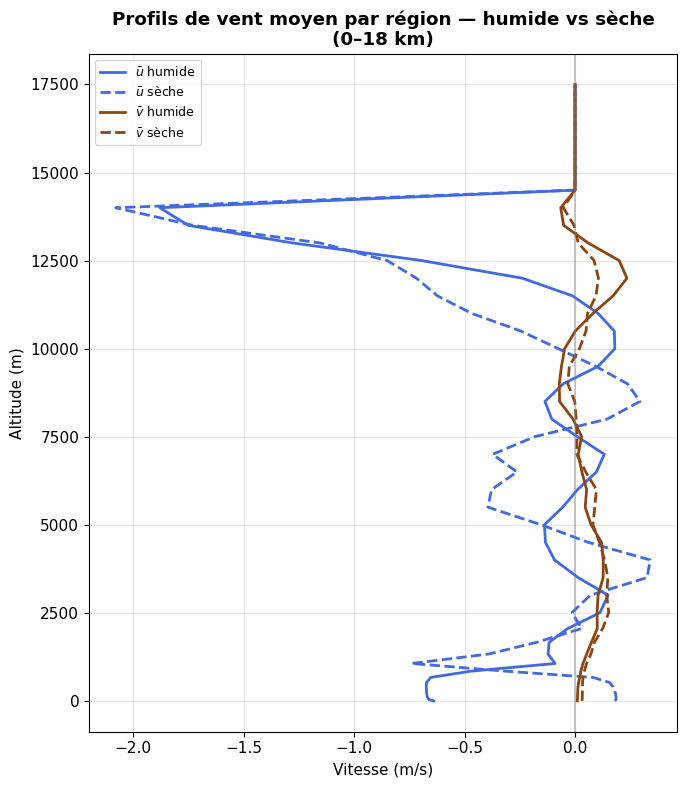

In [17]:
# ======================================================================
# Profils de vent moyen ū et v̄ par région (humide / sèche)
# ======================================================================

fig, ax = plt.subplots(figsize=(7, 8))
idx_18km = np.searchsorted(alt, 18000)
sl = slice(None, idx_18km)

ax.plot(ubar_h[sl], alt[sl], color='royalblue',   lw=2,               label=r'$\bar{u}$ humide')
ax.plot(ubar_s[sl], alt[sl], color='royalblue',   lw=2, linestyle='--', label=r'$\bar{u}$ sèche')
ax.plot(vbar_h[sl], alt[sl], color='saddlebrown', lw=2,               label=r'$\bar{v}$ humide')
ax.plot(vbar_s[sl], alt[sl], color='saddlebrown', lw=2, linestyle='--', label=r'$\bar{v}$ sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('Vitesse (m/s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Profils de vent moyen par région — humide vs sèche\n(0–18 km)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Paramétrisation selon deux axes 

In [24]:
n_stat_it = n_t - t_stat
idx_18km  = np.searchsorted(alt, 18000)

alpha_h = np.zeros((n_stat_it, idx_18km))
beta_h  = np.zeros((n_stat_it, idx_18km))
alpha_s = np.zeros((n_stat_it, idx_18km))
beta_s  = np.zeros((n_stat_it, idx_18km))

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

ubar_glob = np.zeros(idx_18km)
for iz in range(idx_18km):
    for it in range(t_stat, n_t):
        ubar_glob[iz] += ds_u['ua'].isel({dim_t: it, dim_z: iz}).values.mean()
    ubar_glob[iz] /= n_stat_it
print('ubar_glob calculé.')

for iz in range(idx_18km):

    iz_lo = max(iz - 1, 0)
    iz_hi = min(iz + 1, idx_18km - 1)
    dz    = alt[iz_hi] - alt[iz_lo]
    if dz == 0:
        dz = alt[1] - alt[0]

    u_all = ds_u['ua'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    w_all = ds_w['wa'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    u_lo  = ds_u['ua'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    u_hi  = ds_u['ua'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values

    for i_t in range(n_stat_it):

        u_2d = u_all[i_t]
        w_2d = w_all[i_t]

        uw_lo     = (u_lo[i_t] - u_lo[i_t].mean()) * (w_all[i_t] - w_all[i_t].mean())
        uw_hi     = (u_hi[i_t] - u_hi[i_t].mean()) * (w_all[i_t] - w_all[i_t].mean())
        dz_rho_uw = rho0[iz_hi] * uw_hi - rho0[iz_lo] * uw_lo
        tend_2d   = -dz_rho_uw / (dz * rho0[iz])

        uC        = u_2d - ubar_glob[iz]
        rho_uC    = rho0[iz] * uC
        rho_uC_lo = rho0[iz_lo] * (u_lo[i_t] - ubar_glob[iz_lo])
        rho_uC_hi = rho0[iz_hi] * (u_hi[i_t] - ubar_glob[iz_hi])
        dz_rho_uC = (rho_uC_hi - rho_uC_lo) / dz

        for mask, alpha_arr, beta_arr in [
            (mh, alpha_h, beta_h),
            (ms, alpha_s, beta_s),
        ]:
            y  = tend_2d[mask]
            x1 = rho_uC[mask]
            x2 = dz_rho_uC[mask]

            X   = np.stack([x1, x2], axis=1)
            XtX = X.T @ X
            Xty = X.T @ y
            try:
                coeffs = np.linalg.solve(XtX, Xty)
            except np.linalg.LinAlgError:
                coeffs = np.zeros(2)

            alpha_arr[i_t, iz] = coeffs[0]
            beta_arr[i_t, iz]  = coeffs[1]

    del u_all, w_all, u_lo, u_hi
    gc.collect()

    if iz % 10 == 0:
        print(f'  iz={iz}/{idx_18km-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()
print('α, β (u) calculés.')

ubar_glob calculé.
  iz=0/43  (0 m)
  iz=10/43  (1331 m)
  iz=20/43  (6000 m)
  iz=30/43  (11000 m)
  iz=40/43  (16000 m)
α, β (u) calculés.


/tmp/ipykernel_5744/1273935669.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


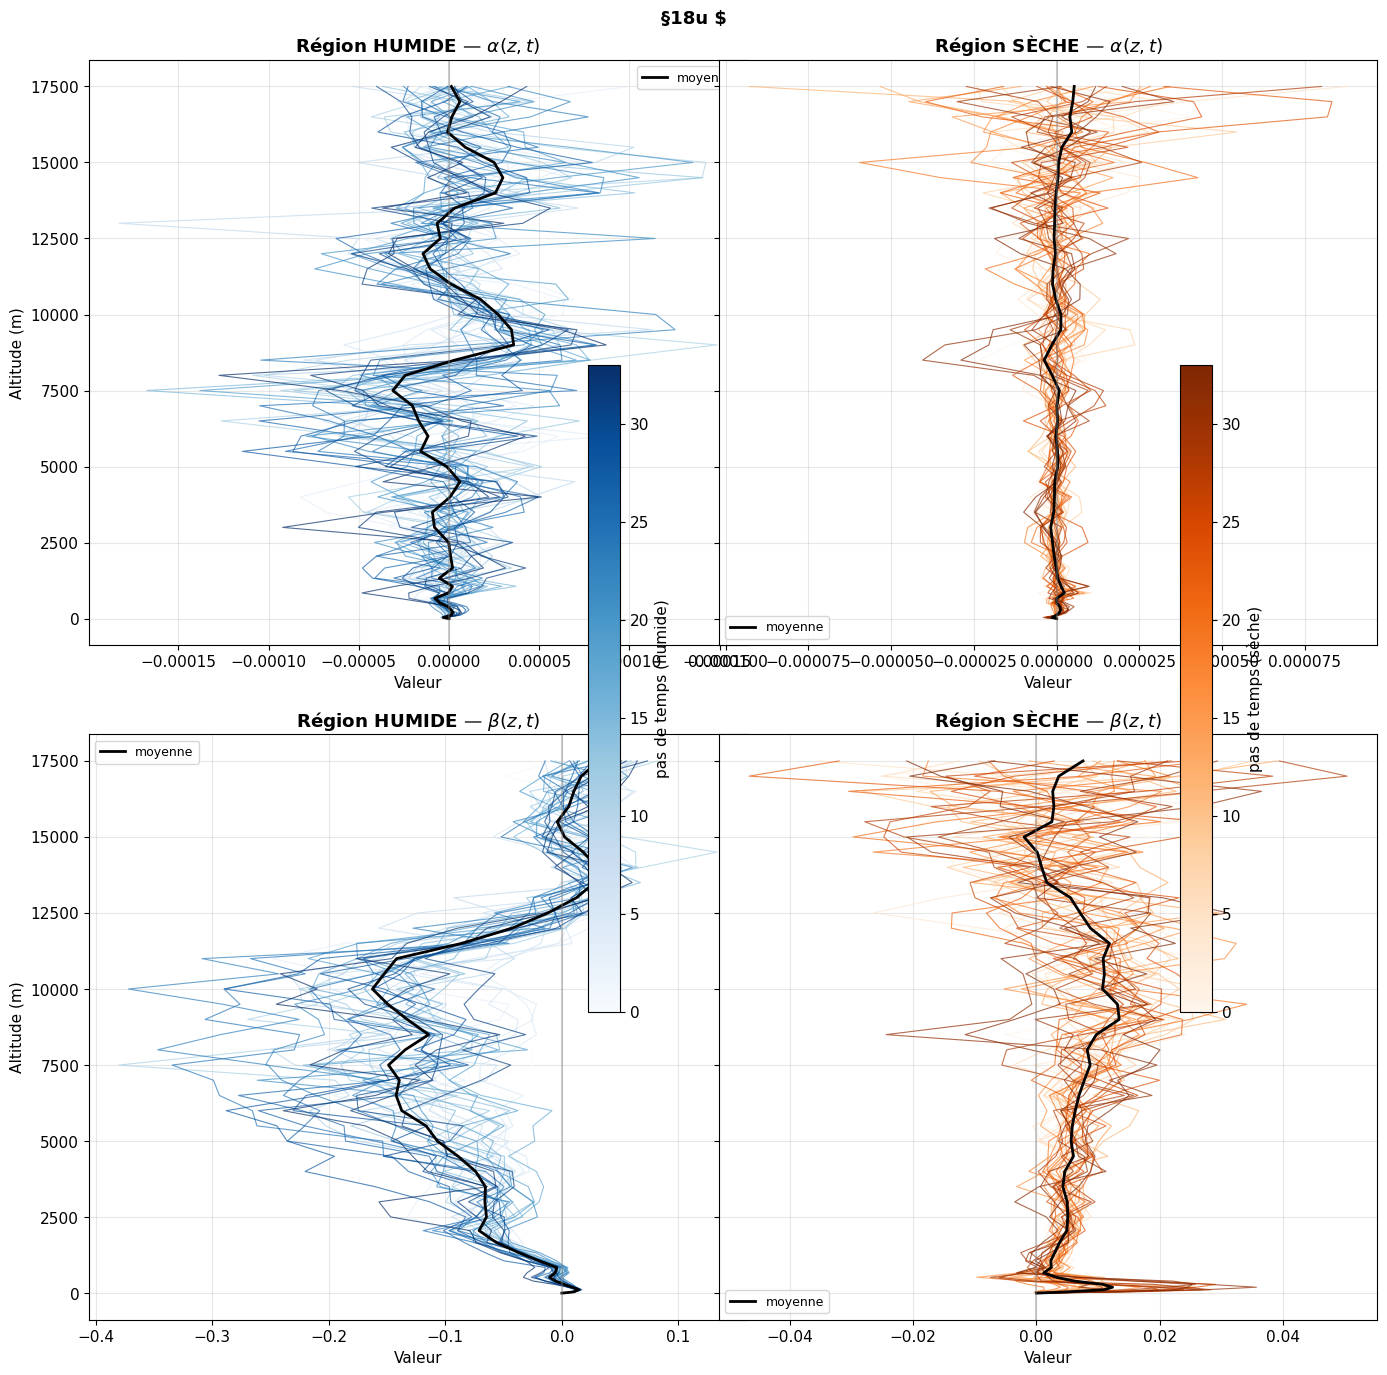

In [26]:
cmap_h = plt.cm.Blues
cmap_s = plt.cm.Oranges
norm   = plt.Normalize(vmin=0, vmax=n_stat_it - 1)
z      = alt[:idx_18km]

fig, axes = plt.subplots(2, 2, figsize=(14, 14), sharey=True)

for col, (alpha_arr, beta_arr, label, cmap) in enumerate([
    (alpha_h, beta_h, 'HUMIDE', cmap_h),
    (alpha_s, beta_s, 'SÈCHE',  cmap_s),
]):
    ax_a = axes[0, col]
    ax_b = axes[1, col]

    for i_t in range(n_stat_it):
        c = cmap(norm(i_t))
        ax_a.plot(alpha_arr[i_t], z, color=c, lw=0.8, alpha=0.7)
        ax_b.plot(beta_arr[i_t],  z, color=c, lw=0.8, alpha=0.7)

    ax_a.plot(alpha_arr.mean(axis=0), z, color='black', lw=2, label='moyenne')
    ax_b.plot(beta_arr.mean(axis=0),  z, color='black', lw=2, label='moyenne')

    for ax, nom in [(ax_a, r'$\alpha(z,t)$'), (ax_b, r'$\beta(z,t)$')]:
        ax.axvline(0, color='grey', alpha=0.4)
        ax.set_title(f'Région {label} — {nom}', fontweight='bold')
        ax.set_xlabel('Valeur')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

axes[0, 0].set_ylabel('Altitude (m)')
axes[1, 0].set_ylabel('Altitude (m)')

sm = plt.cm.ScalarMappable(cmap=cmap_h, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[:, 0], label='pas de temps (humide)', shrink=0.6)
sm2 = plt.cm.ScalarMappable(cmap=cmap_s, norm=norm)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[:, 1], label='pas de temps (sèche)', shrink=0.6)

plt.suptitle(
    r'§18u $',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [27]:
alpha_v_h = np.zeros((n_stat_it, idx_18km))
beta_v_h  = np.zeros((n_stat_it, idx_18km))
alpha_v_s = np.zeros((n_stat_it, idx_18km))
beta_v_s  = np.zeros((n_stat_it, idx_18km))

ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

vbar_glob = np.zeros(idx_18km)
for iz in range(idx_18km):
    for it in range(t_stat, n_t):
        vbar_glob[iz] += ds_v['va'].isel({dim_t: it, dim_z: iz}).values.mean()
    vbar_glob[iz] /= n_stat_it
print('vbar_glob calculé.')

for iz in range(idx_18km):

    iz_lo = max(iz - 1, 0)
    iz_hi = min(iz + 1, idx_18km - 1)
    dz    = alt[iz_hi] - alt[iz_lo]
    if dz == 0:
        dz = alt[1] - alt[0]

    v_all = ds_v['va'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    w_all = ds_w['wa'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    v_lo  = ds_v['va'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    v_hi  = ds_v['va'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values

    for i_t in range(n_stat_it):

        v_2d = v_all[i_t]
        w_2d = w_all[i_t]

        vw_lo     = (v_lo[i_t] - v_lo[i_t].mean()) * (w_all[i_t] - w_all[i_t].mean())
        vw_hi     = (v_hi[i_t] - v_hi[i_t].mean()) * (w_all[i_t] - w_all[i_t].mean())
        dz_rho_vw = rho0[iz_hi] * vw_hi - rho0[iz_lo] * vw_lo
        tend_2d   = -dz_rho_vw / (dz * rho0[iz])

        vC        = v_2d - vbar_glob[iz]
        rho_vC    = rho0[iz] * vC
        rho_vC_lo = rho0[iz_lo] * (v_lo[i_t] - vbar_glob[iz_lo])
        rho_vC_hi = rho0[iz_hi] * (v_hi[i_t] - vbar_glob[iz_hi])
        dz_rho_vC = (rho_vC_hi - rho_vC_lo) / dz

        for mask, alpha_arr, beta_arr in [
            (mh, alpha_v_h, beta_v_h),
            (ms, alpha_v_s, beta_v_s),
        ]:
            y  = tend_2d[mask]
            x1 = rho_vC[mask]
            x2 = dz_rho_vC[mask]

            X   = np.stack([x1, x2], axis=1)
            XtX = X.T @ X
            Xty = X.T @ y
            try:
                coeffs = np.linalg.solve(XtX, Xty)
            except np.linalg.LinAlgError:
                coeffs = np.zeros(2)

            alpha_arr[i_t, iz] = coeffs[0]
            beta_arr[i_t, iz]  = coeffs[1]

    del v_all, w_all, v_lo, v_hi
    gc.collect()

    if iz % 10 == 0:
        print(f'  iz={iz}/{idx_18km-1}  ({alt[iz]:.0f} m)')

ds_v.close() ; ds_w.close()
del ds_v, ds_w
gc.collect()
print('α, β (v) calculés.')

vbar_glob calculé.
  iz=0/43  (0 m)
  iz=10/43  (1331 m)
  iz=20/43  (6000 m)
  iz=30/43  (11000 m)
  iz=40/43  (16000 m)
α, β (v) calculés.


/tmp/ipykernel_5744/1259521144.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


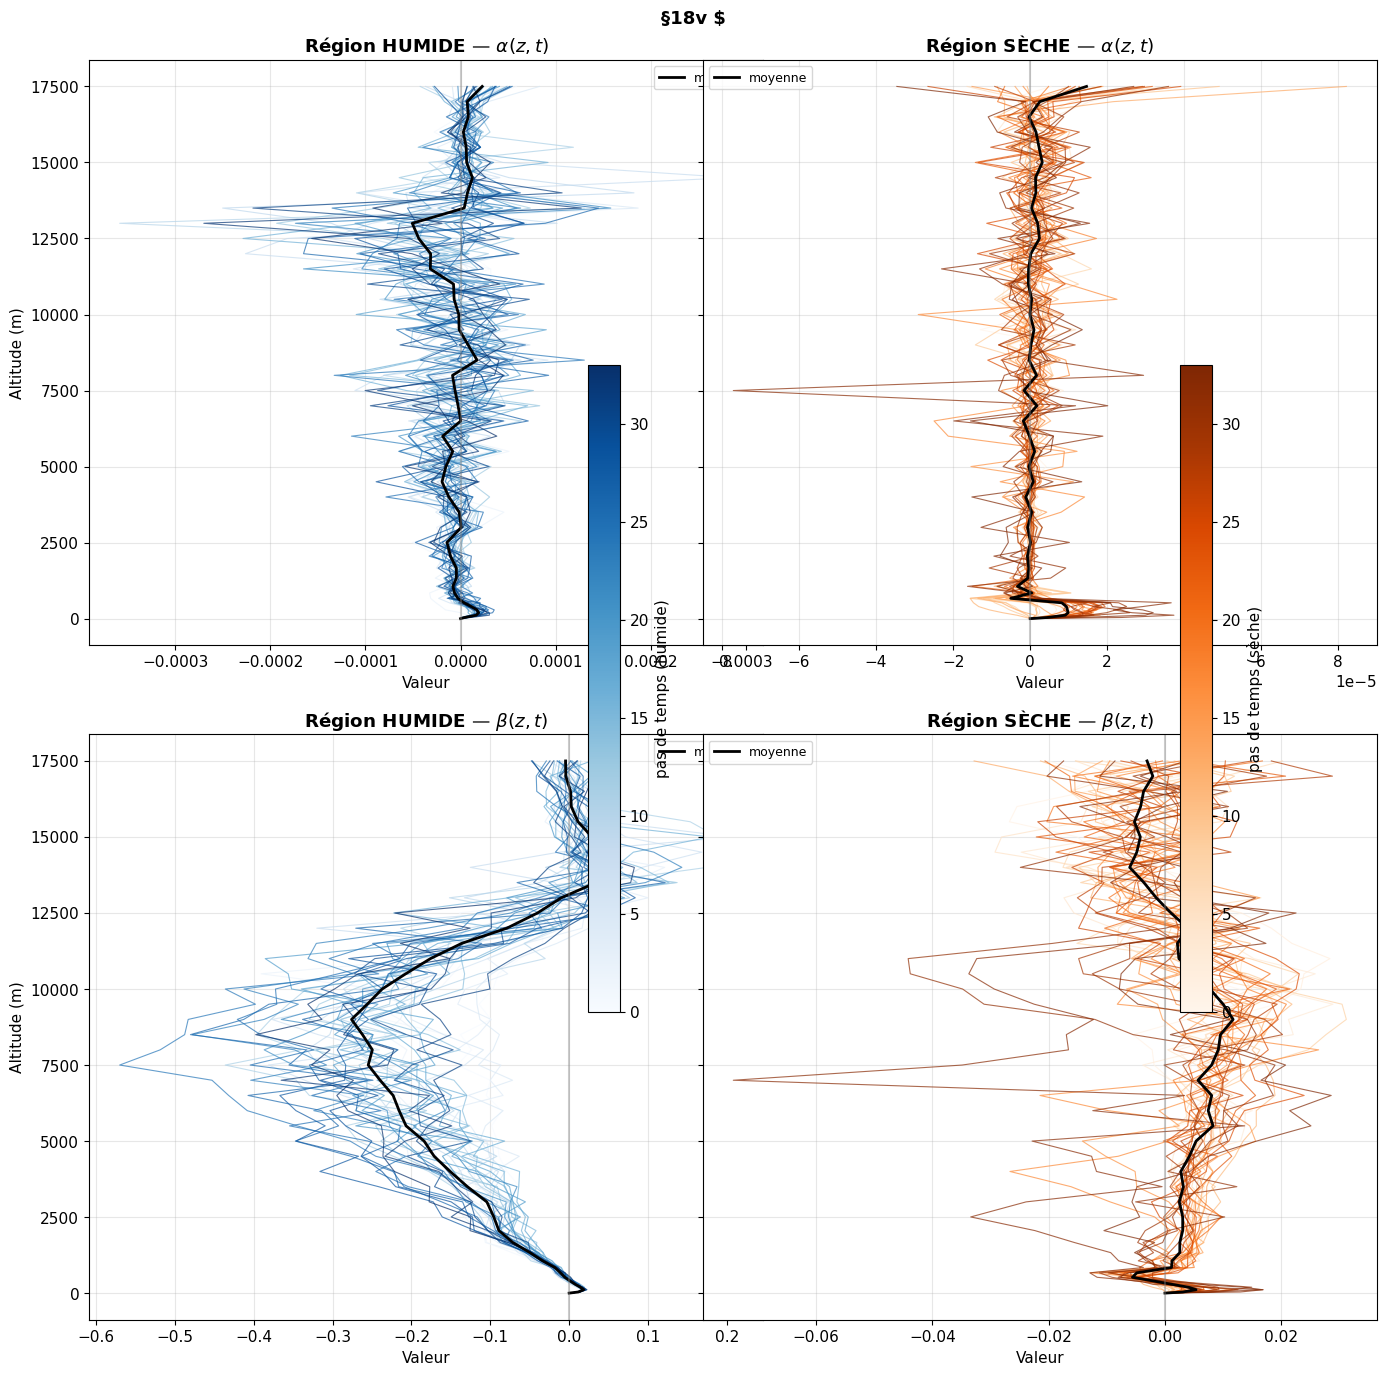

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), sharey=True)

for col, (alpha_arr, beta_arr, label, cmap) in enumerate([
    (alpha_v_h, beta_v_h, 'HUMIDE', cmap_h),
    (alpha_v_s, beta_v_s, 'SÈCHE',  cmap_s),
]):
    ax_a = axes[0, col]
    ax_b = axes[1, col]

    for i_t in range(n_stat_it):
        c = cmap(norm(i_t))
        ax_a.plot(alpha_arr[i_t], z, color=c, lw=0.8, alpha=0.7)
        ax_b.plot(beta_arr[i_t],  z, color=c, lw=0.8, alpha=0.7)

    ax_a.plot(alpha_arr.mean(axis=0), z, color='black', lw=2, label='moyenne')
    ax_b.plot(beta_arr.mean(axis=0),  z, color='black', lw=2, label='moyenne')

    for ax, nom in [(ax_a, r'$\alpha(z,t)$'), (ax_b, r'$\beta(z,t)$')]:
        ax.axvline(0, color='grey', alpha=0.4)
        ax.set_title(f'Région {label} — {nom}', fontweight='bold')
        ax.set_xlabel('Valeur')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

axes[0, 0].set_ylabel('Altitude (m)')
axes[1, 0].set_ylabel('Altitude (m)')

sm = plt.cm.ScalarMappable(cmap=cmap_h, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[:, 0], label='pas de temps (humide)', shrink=0.6)
sm2 = plt.cm.ScalarMappable(cmap=cmap_s, norm=norm)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[:, 1], label='pas de temps (sèche)', shrink=0.6)

plt.suptitle(
    r'§18v $',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [44]:
iz_lo_glob = np.searchsorted(alt, 2000)
iz_hi_glob = np.searchsorted(alt, 18000)
n_z_fit    = iz_hi_glob - iz_lo_glob
z_fit_ab   = alt[iz_lo_glob:iz_hi_glob]

alpha_h = np.zeros(n_z_fit)
beta_h  = np.zeros(n_z_fit)
alpha_s = np.zeros(n_z_fit)
beta_s  = np.zeros(n_z_fit)

y_mean_h  = np.zeros(n_z_fit)
y_mean_s  = np.zeros(n_z_fit)
yhat_mean_h = np.zeros(n_z_fit)
yhat_mean_s = np.zeros(n_z_fit)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

# ── ubar_glob(iz) : moyenne domaine entier sur l'état stationnaire ────
ubar_glob = np.zeros(n_z_fit)
for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):
    for it in range(t_stat, n_t):
        ubar_glob[i_iz] += ds_u['ua'].isel({dim_t: it, dim_z: iz}).values.mean()
    ubar_glob[i_iz] /= n_stat_it
print('ubar_glob calculé.')

# ── Boucle principale : un niveau à la fois ───────────────────────────
for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):

    iz_lo = iz - 1
    iz_hi = iz + 1
    dz    = alt[iz_hi] - alt[iz_lo]

    u_all = ds_u['ua'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    u_lo  = ds_u['ua'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    u_hi  = ds_u['ua'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values
    w_lo  = ds_w['wa'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    w_hi  = ds_w['wa'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values

    # ── scalaires y(t), x1(t), x2(t) pour chaque région ─────────────
    y_t_h  = np.zeros(n_stat_it) ; y_t_s  = np.zeros(n_stat_it)
    x1_t_h = np.zeros(n_stat_it) ; x1_t_s = np.zeros(n_stat_it)
    x2_t_h = np.zeros(n_stat_it) ; x2_t_s = np.zeros(n_stat_it)

    for i_t in range(n_stat_it):

        # y : divergence du flux Reynolds moyen sur la région
        u_p_lo = u_lo[i_t] - u_lo[i_t].mean()
        w_p_lo = w_lo[i_t] - w_lo[i_t].mean()
        u_p_hi = u_hi[i_t] - u_hi[i_t].mean()
        w_p_hi = w_hi[i_t] - w_hi[i_t].mean()

        flux_lo_h = (rho0[iz_lo] * u_p_lo * w_p_lo)[mh].mean()
        flux_hi_h = (rho0[iz_hi] * u_p_hi * w_p_hi)[mh].mean()
        flux_lo_s = (rho0[iz_lo] * u_p_lo * w_p_lo)[ms].mean()
        flux_hi_s = (rho0[iz_hi] * u_p_hi * w_p_hi)[ms].mean()

        y_t_h[i_t] = -(flux_hi_h - flux_lo_h) / (dz * rho0[iz])
        y_t_s[i_t] = -(flux_hi_s - flux_lo_s) / (dz * rho0[iz])

        # x1 : rho0 * ubar_reg
        x1_t_h[i_t] = rho0[iz] * u_all[i_t][mh].mean()
        x1_t_s[i_t] = rho0[iz] * u_all[i_t][ms].mean()

        # x2 : dz(rho0 * ubar_reg) par différences finies centrées
        x2_t_h[i_t] = (rho0[iz_hi] * u_hi[i_t][mh].mean()
                      - rho0[iz_lo] * u_lo[i_t][mh].mean()) / dz
        x2_t_s[i_t] = (rho0[iz_hi] * u_hi[i_t][ms].mean()
                      - rho0[iz_lo] * u_lo[i_t][ms].mean()) / dz

    # ── OLS sur t par région ──────────────────────────────────────────
    for y_t, x1_t, x2_t, alpha_arr, beta_arr, tag in [
        (y_t_h, x1_t_h, x2_t_h, alpha_h, beta_h, 'h'),
        (y_t_s, x1_t_s, x2_t_s, alpha_s, beta_s, 's'),
    ]:
        S11 = x1_t @ x1_t
        S12 = x1_t @ x2_t
        S22 = x2_t @ x2_t
        b1  = x1_t @ y_t
        b2  = x2_t @ y_t

        det = S11 * S22 - S12 * S12
        a   = ( S22 * b1 - S12 * b2) / det
        b   = (-S12 * b1 + S11 * b2) / det

        if tag == 'h':
            alpha_h[i_iz] = a ; beta_h[i_iz] = b
            y_mean_h[i_iz]    = y_t.mean()
            yhat_mean_h[i_iz] = (a * x1_t + b * x2_t).mean()
        else:
            alpha_s[i_iz] = a ; beta_s[i_iz] = b
            y_mean_s[i_iz]    = y_t.mean()
            yhat_mean_s[i_iz] = (a * x1_t + b * x2_t).mean()

    del u_all, u_lo, u_hi, w_lo, w_hi
    gc.collect()

    if i_iz % 10 == 0:
        print(f'  i_iz={i_iz}/{n_z_fit-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()
print('α(z), β(z) calculés.')


ubar_glob calculé.
  i_iz=0/31  (2055 m)
  i_iz=10/31  (7000 m)
  i_iz=20/31  (12000 m)
  i_iz=30/31  (17000 m)
α(z), β(z) calculés.


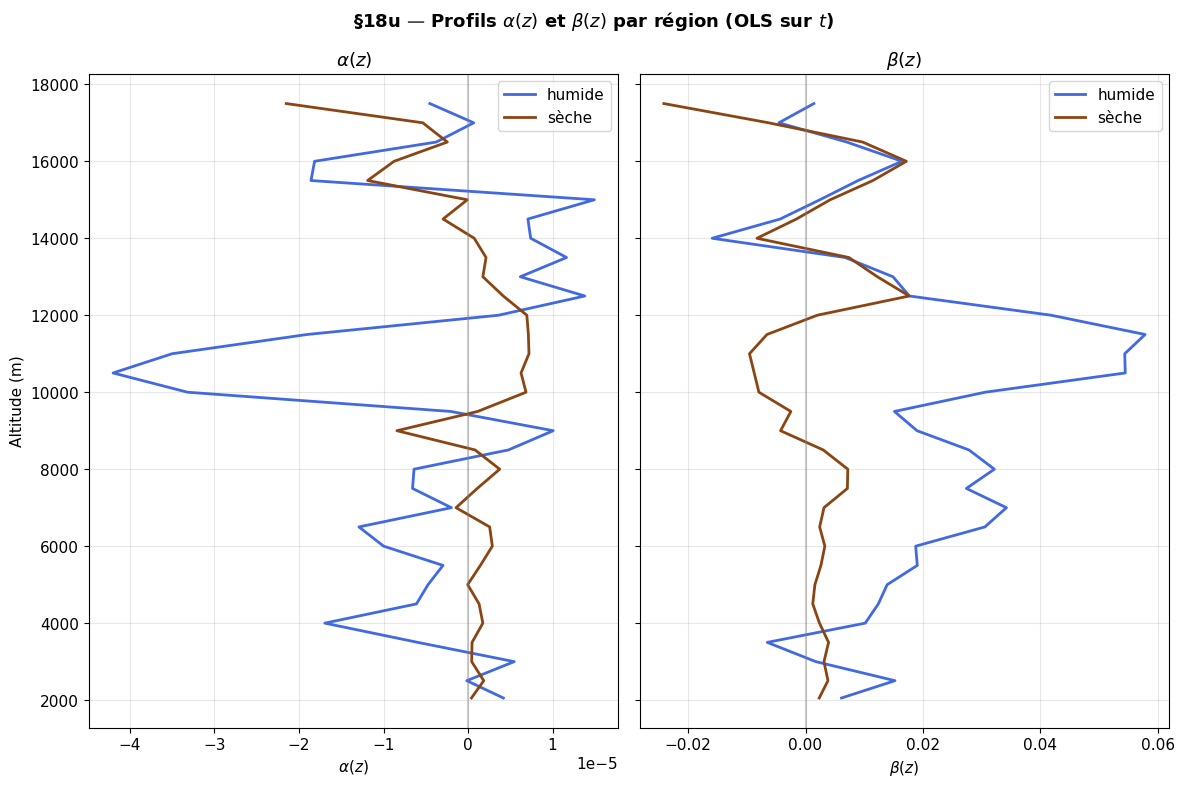

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

axes[0].plot(alpha_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[0].plot(alpha_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[0].axvline(0, color='grey', alpha=0.4)
axes[0].set_xlabel(r'$\alpha(z)$')
axes[0].set_ylabel('Altitude (m)')
axes[0].set_title(r'$\alpha(z)$', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(beta_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[1].plot(beta_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[1].axvline(0, color='grey', alpha=0.4)
axes[1].set_xlabel(r'$\beta(z)$')
axes[1].set_title(r'$\beta(z)$', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(r'§18u — Profils $\alpha(z)$ et $\beta(z)$ par région (OLS sur $t$)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

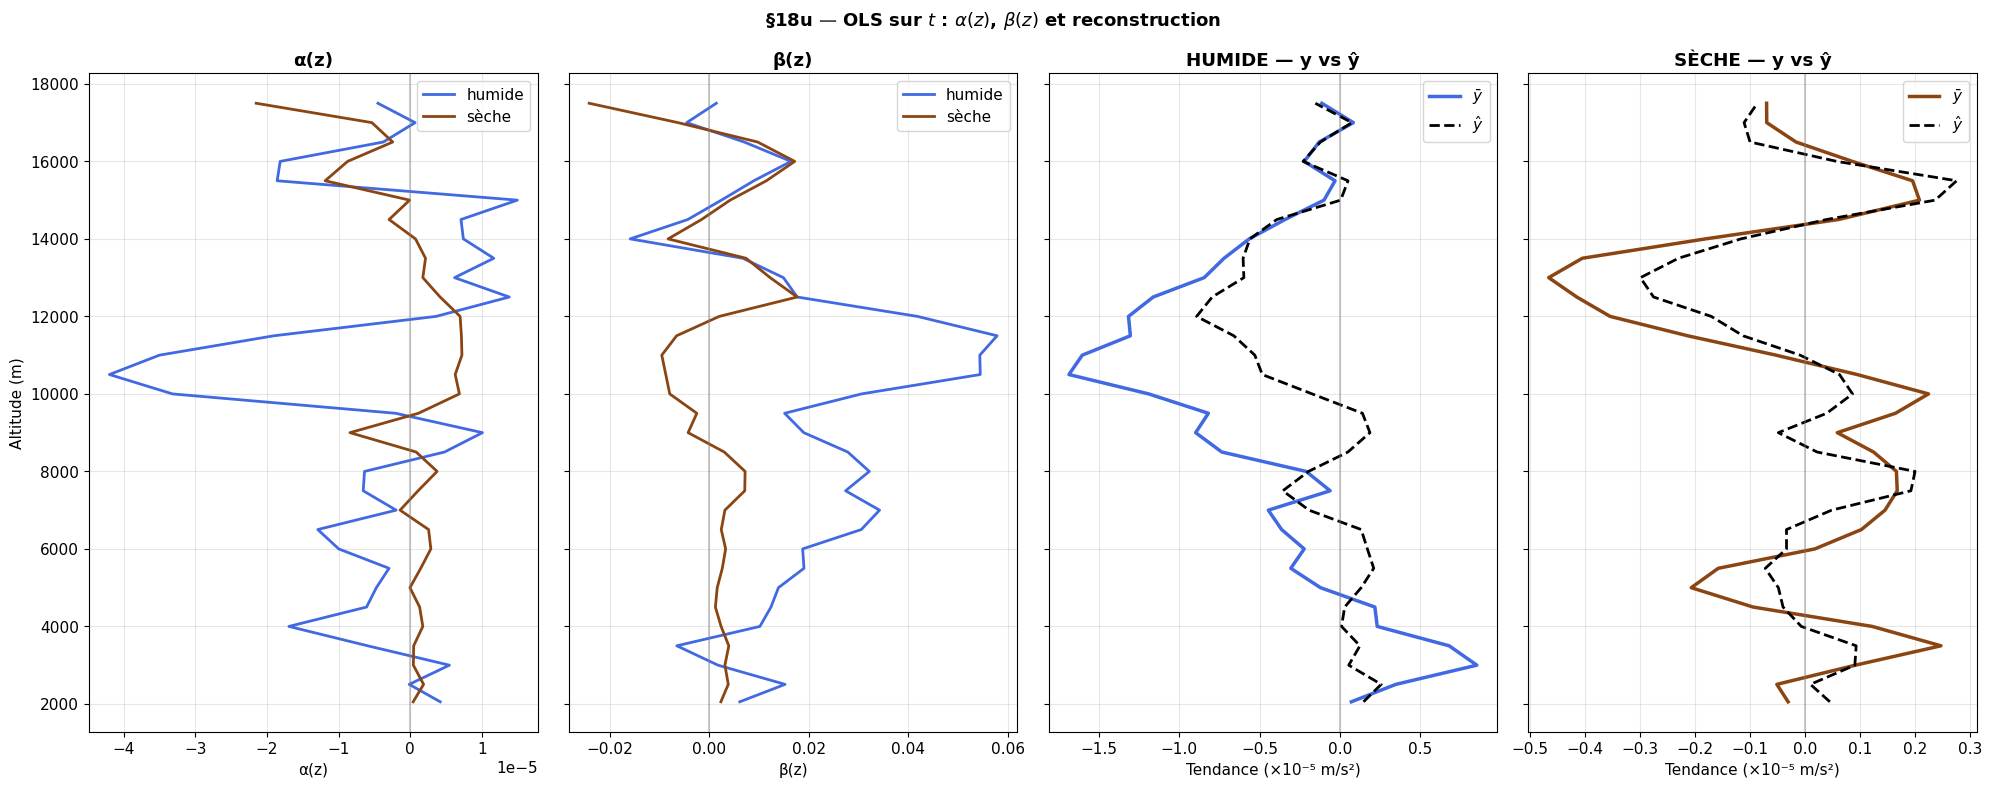

In [45]:
# ── Visualisation α(z) et β(z) + comparaison y vs ŷ ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)

axes[0].plot(alpha_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[0].plot(alpha_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[0].axvline(0, color='grey', alpha=0.4)
axes[0].set_xlabel('α(z)')
axes[0].set_title('α(z)', fontweight='bold')
axes[0].legend() ; axes[0].grid(True, alpha=0.3)

axes[1].plot(beta_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[1].plot(beta_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[1].axvline(0, color='grey', alpha=0.4)
axes[1].set_xlabel('β(z)')
axes[1].set_title('β(z)', fontweight='bold')
axes[1].legend() ; axes[1].grid(True, alpha=0.3)

axes[2].plot(y_mean_h    * 1e5, z_fit_ab, color='royalblue', lw=2.5, label=r'$\bar{y}$')
axes[2].plot(yhat_mean_h * 1e5, z_fit_ab, color='black',     lw=2, linestyle='--', label=r'$\hat{y}$')
axes[2].axvline(0, color='grey', alpha=0.4)
axes[2].set_xlabel('Tendance (×10⁻⁵ m/s²)')
axes[2].set_title('HUMIDE — y vs ŷ', fontweight='bold')
axes[2].legend() ; axes[2].grid(True, alpha=0.3)

axes[3].plot(y_mean_s    * 1e5, z_fit_ab, color='saddlebrown', lw=2.5, label=r'$\bar{y}$')
axes[3].plot(yhat_mean_s * 1e5, z_fit_ab, color='black',       lw=2, linestyle='--', label=r'$\hat{y}$')
axes[3].axvline(0, color='grey', alpha=0.4)
axes[3].set_xlabel('Tendance (×10⁻⁵ m/s²)')
axes[3].set_title('SÈCHE — y vs ŷ', fontweight='bold')
axes[3].legend() ; axes[3].grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(r'§18u — OLS sur $t$ : $\alpha(z)$, $\beta(z)$ et reconstruction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()